
--- Dataset Overview ---
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  .

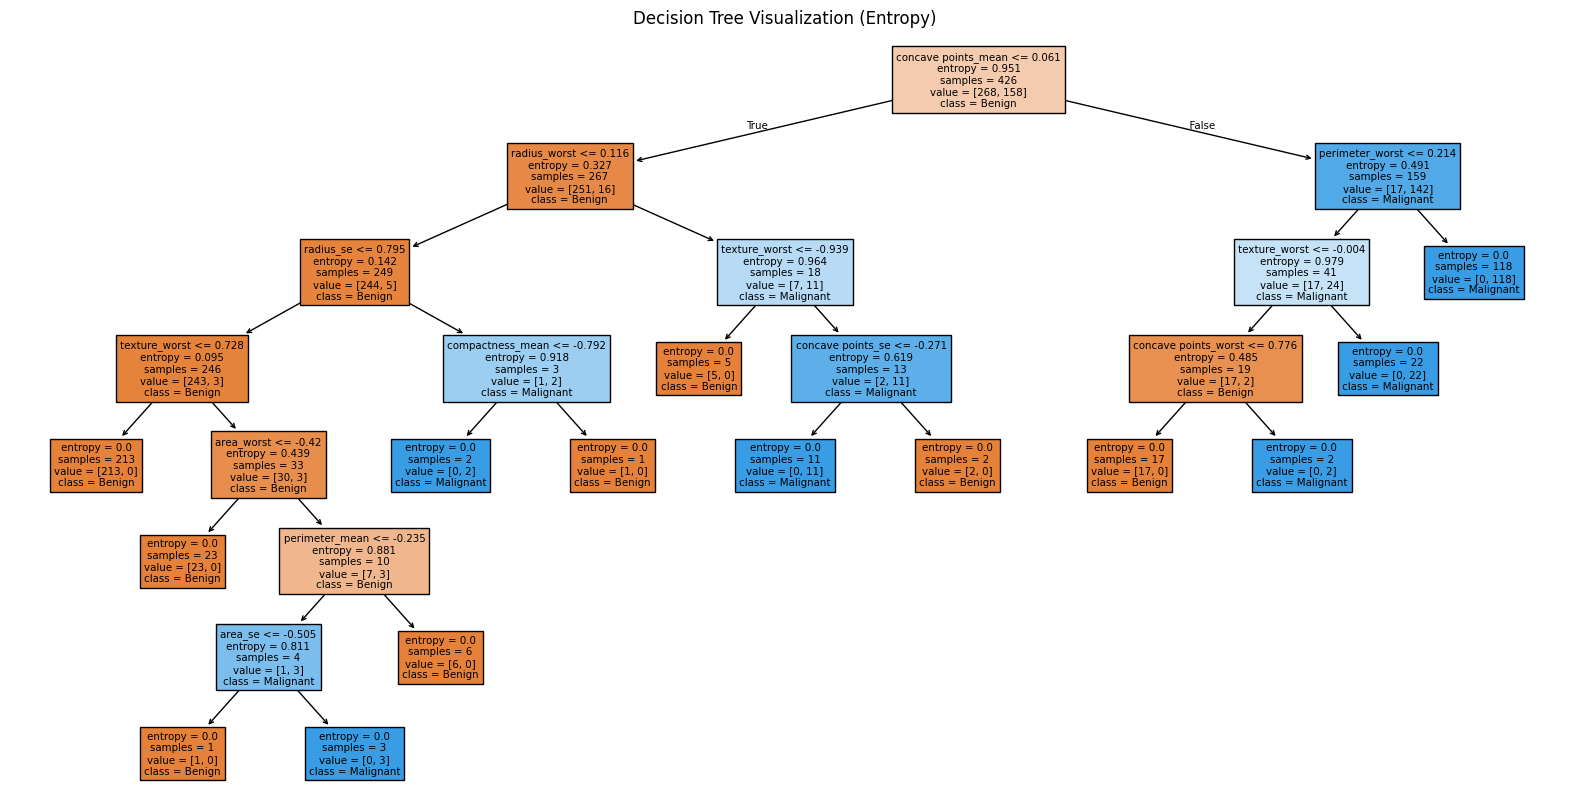


--- EVALUATION METHODS ---

Hold-Out Method with Test Size: 0.2
Naive Bayes Accuracy: 0.9649
KNN Accuracy: 0.9474
Decision Tree (Gini) Accuracy: 0.9386
Decision Tree (Entropy) Accuracy: 0.9561

Hold-Out Method with Test Size: 0.333
Naive Bayes Accuracy: 0.9368
KNN Accuracy: 0.9579
Decision Tree (Gini) Accuracy: 0.9211
Decision Tree (Entropy) Accuracy: 0.9526

5-Fold Cross Validation
Naive Bayes Accuracy: 0.9367
KNN Accuracy: 0.9595
Decision Tree (Gini) Accuracy: 0.9420
Decision Tree (Entropy) Accuracy: 0.9367

10-Fold Cross Validation
Naive Bayes Accuracy: 0.9279
KNN Accuracy: 0.9648
Decision Tree (Gini) Accuracy: 0.9210
Decision Tree (Entropy) Accuracy: 0.9367

--- Association Rules ---
Empty DataFrame
Columns: [antecedents, consequents, support, confidence]
Index: []


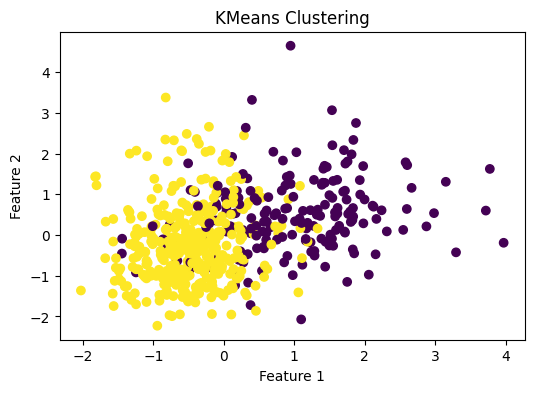

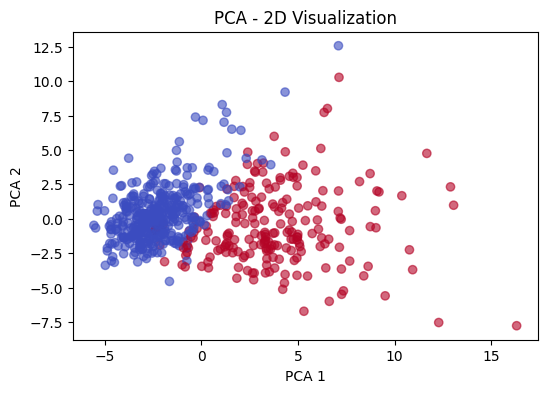


SUMMARY OUTPUT:
1. Preprocessing: Scaling, Normalization, Log Transform, Binarization, Discretization
2. Classification: Naive Bayes, KNN, Decision Trees with evaluation metrics
3. Decision Tree Visualized using Entropy criteria
4. Evaluation: Hold-out and K-Fold cross-validation
5. Association Rule Mining: Apriori algorithm with binary conversion
6. Clustering: K-Means with visualization
7. Dimensionality Reduction: PCA visualization
8. Applications for medical diagnosis and real-time healthcare systems



In [ ]:
# Breast Cancer Wisconsin Dataset - Full Data Mining Project (Colab Ready Version)

# ---------------------------
# IMPORTING LIBRARIES
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# LOADING THE DATASET
# ---------------------------
df = pd.read_csv('/content/breast-cancer-wisconsin-data_data.csv')

# Drop ID and unnamed column if exists
df = df.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in df.columns])

# Encode Diagnosis column
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop any remaining NaNs (if any)
df.dropna(inplace=True)

print("\n--- Dataset Overview ---")
print(df.head())
print("\nDataset Shape:", df.shape)

# ---------------------------
# APPLICATIONS
# ---------------------------
print("""
APPLICATIONS:
1. Assists doctors in early and accurate breast cancer diagnosis.
2. Reduces the need for invasive biopsy procedures.
3. Enhances patient care by using predictive modeling.
4. Supports real-time decision making in healthcare systems.
5. Demonstrates how data mining techniques can be used across real-world datasets.
""")

# ---------------------------
# PREPROCESSING TECHNIQUES
# ---------------------------
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled.iloc[:, 1:] = scaler.fit_transform(df_scaled.iloc[:, 1:])

normalizer = MinMaxScaler()
df_normalized = df.copy()
df_normalized.iloc[:, 1:] = normalizer.fit_transform(df_normalized.iloc[:, 1:])

df_log = df.copy()
df_log['radius_mean'] = np.log1p(df_log['radius_mean'])

df_binarized = df.copy()
binarizer = Binarizer(threshold=14)
df_binarized['radius_mean'] = binarizer.fit_transform(df[['radius_mean']])

df_discretized = df.copy()
df_discretized['radius_cat'] = pd.cut(df['radius_mean'], bins=[0, 10, 15, 20, 30], labels=['Small', 'Medium', 'Large', 'Very Large'])

df_sampled = df.sample(frac=0.3, random_state=42)

# ---------------------------
# CLASSIFICATION MODELS
# ---------------------------
def evaluate_model(name, model, X, y):
    print(f"\n{name}")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return model

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_scaled = StandardScaler().fit_transform(X)

# Evaluate models
nb_model = evaluate_model("Naive Bayes", GaussianNB(), X_scaled, y)
knn_model = evaluate_model("K-Nearest Neighbors", KNeighborsClassifier(), X_scaled, y)
dt_gini_model = evaluate_model("Decision Tree (Gini)", DecisionTreeClassifier(criterion='gini'), X_scaled, y)
dt_entropy_model = evaluate_model("Decision Tree (Entropy)", DecisionTreeClassifier(criterion='entropy'), X_scaled, y)

# ---------------------------
# VISUALIZE DECISION TREE
# ---------------------------
plt.figure(figsize=(20,10))
plot_tree(dt_entropy_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree Visualization (Entropy)")
plt.show()

# ---------------------------
# EVALUATION TECHNIQUES
# ---------------------------
print("\n--- EVALUATION METHODS ---")
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini'),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion='entropy')
}

for test_size in [0.2, 0.333]:
    print(f"\nHold-Out Method with Test Size: {test_size}")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {acc:.4f}")

for k in [5, 10]:
    print(f"\n{k}-Fold Cross Validation")
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for name, model in models.items():
        scores = cross_val_score(model, X_scaled, y, cv=kf)
        print(f"{name} Accuracy: {scores.mean():.4f}")

# ---------------------------
# ASSOCIATION RULE MINING
# ---------------------------
bin_df = df[['radius_mean', 'texture_mean']].copy()
bin_df['radius_mean'] = bin_df['radius_mean'] > 14
bin_df['texture_mean'] = bin_df['texture_mean'] > 20
bin_df = bin_df.astype(bool)

te = TransactionEncoder()
te_ary = te.fit_transform(bin_df.values.tolist())
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_apriori, min_support=0.5, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.75)

print("\n--- Association Rules ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence']])

# ---------------------------
# CLUSTERING WITH K-MEANS
# ---------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

plt.figure(figsize=(6, 4))
plt.title("KMeans Clustering")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# ---------------------------
# PCA - DIMENSIONALITY REDUCTION
# ---------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 4))
plt.title("PCA - 2D Visualization")
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# ---------------------------
# OUTPUT SUMMARY
# ---------------------------
print("""
SUMMARY OUTPUT:
1. Preprocessing: Scaling, Normalization, Log Transform, Binarization, Discretization
2. Classification: Naive Bayes, KNN, Decision Trees with evaluation metrics
3. Decision Tree Visualized using Entropy criteria
4. Evaluation: Hold-out and K-Fold cross-validation
5. Association Rule Mining: Apriori algorithm with binary conversion
6. Clustering: K-Means with visualization
7. Dimensionality Reduction: PCA visualization
8. Applications for medical diagnosis and real-time healthcare systems
""")



--- Dataset Overview ---
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  .

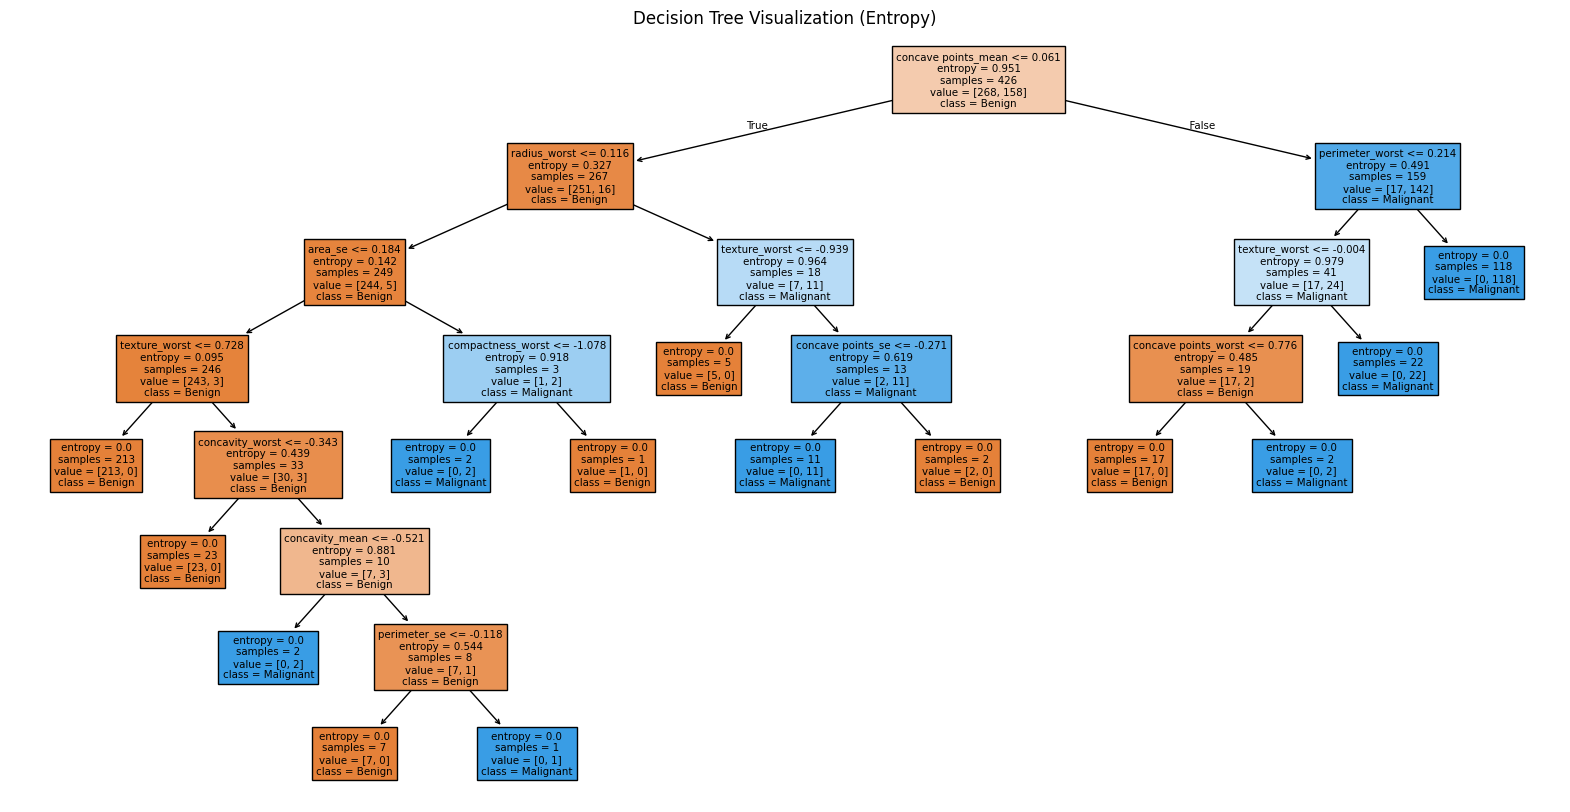


--- EVALUATION METHODS ---

Hold-Out Method with Test Size: 0.2
Naive Bayes Accuracy: 0.9649
KNN Accuracy: 0.9474
Decision Tree (Gini) Accuracy: 0.9298
Decision Tree (Entropy) Accuracy: 0.9561

Hold-Out Method with Test Size: 0.333
Naive Bayes Accuracy: 0.9368
KNN Accuracy: 0.9579
Decision Tree (Gini) Accuracy: 0.9263
Decision Tree (Entropy) Accuracy: 0.9684

5-Fold Cross Validation
Naive Bayes Accuracy: 0.9367
KNN Accuracy: 0.9595
Decision Tree (Gini) Accuracy: 0.9367
Decision Tree (Entropy) Accuracy: 0.9297

10-Fold Cross Validation
Naive Bayes Accuracy: 0.9279
KNN Accuracy: 0.9648
Decision Tree (Gini) Accuracy: 0.9333
Decision Tree (Entropy) Accuracy: 0.9403

--- Association Rules ---
Empty DataFrame
Columns: [antecedents, consequents, support, confidence]
Index: []


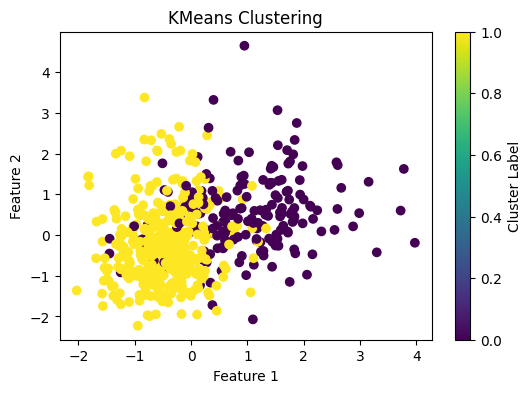


SUMMARY OUTPUT:
1. Preprocessing: Scaling, Normalization, Log Transform, Binarization, Discretization
2. Classification: Naive Bayes, KNN, Decision Trees with evaluation metrics
3. Decision Tree Visualized using Entropy criteria
4. Evaluation: Hold-out and K-Fold cross-validation
5. Association Rule Mining: Apriori algorithm with binary conversion
6. Clustering: K-Means with visualization
7. Applications for medical diagnosis and real-time healthcare systems



In [ ]:
# ---------------------------
# IMPORTING LIBRARIES
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, Binarizer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# LOADING THE DATASET
# ---------------------------
df = pd.read_csv('/content/breast-cancer-wisconsin-data_data.csv')

# Drop ID and unnamed column if exists
df = df.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in df.columns])

# Encode Diagnosis column
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop any remaining NaNs (if any)
df.dropna(inplace=True)

print("\n--- Dataset Overview ---")
print(df.head())
print("\nDataset Shape:", df.shape)

# ---------------------------
# APPLICATIONS
# ---------------------------
print("""
APPLICATIONS:
1. Assists doctors in early and accurate breast cancer diagnosis.
2. Reduces the need for invasive biopsy procedures.
3. Enhances patient care by using predictive modeling.
4. Supports real-time decision making in healthcare systems.
5. Demonstrates how data mining techniques can be used across real-world datasets.
""")

# ---------------------------
# PREPROCESSING TECHNIQUES
# ---------------------------
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled.iloc[:, 1:] = scaler.fit_transform(df_scaled.iloc[:, 1:])

normalizer = MinMaxScaler()
df_normalized = df.copy()
df_normalized.iloc[:, 1:] = normalizer.fit_transform(df_normalized.iloc[:, 1:])

df_log = df.copy()
df_log['radius_mean'] = np.log1p(df_log['radius_mean'])

df_binarized = df.copy()
binarizer = Binarizer(threshold=14)
df_binarized['radius_mean'] = binarizer.fit_transform(df[['radius_mean']])

df_discretized = df.copy()
df_discretized['radius_cat'] = pd.cut(df['radius_mean'], bins=[0, 10, 15, 20, 30], labels=['Small', 'Medium', 'Large', 'Very Large'])

df_sampled = df.sample(frac=0.3, random_state=42)

# ---------------------------
# CLASSIFICATION MODELS
# ---------------------------
def evaluate_model(name, model, X, y):
    print(f"\n{name}")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    return model

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_scaled = StandardScaler().fit_transform(X)

# Evaluate models
nb_model = evaluate_model("Naive Bayes", GaussianNB(), X_scaled, y)
knn_model = evaluate_model("K-Nearest Neighbors", KNeighborsClassifier(), X_scaled, y)
dt_gini_model = evaluate_model("Decision Tree (Gini)", DecisionTreeClassifier(criterion='gini'), X_scaled, y)
dt_entropy_model = evaluate_model("Decision Tree (Entropy)", DecisionTreeClassifier(criterion='entropy'), X_scaled, y)

# ---------------------------
# VISUALIZE DECISION TREE
# ---------------------------
plt.figure(figsize=(20,10))
plot_tree(dt_entropy_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree Visualization (Entropy)")
plt.show()

# ---------------------------
# EVALUATION TECHNIQUES
# ---------------------------
print("\n--- EVALUATION METHODS ---")
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini'),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion='entropy')
}

for test_size in [0.2, 0.333]:
    print(f"\nHold-Out Method with Test Size: {test_size}")
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {acc:.4f}")

for k in [5, 10]:
    print(f"\n{k}-Fold Cross Validation")
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for name, model in models.items():
        scores = cross_val_score(model, X_scaled, y, cv=kf)
        print(f"{name} Accuracy: {scores.mean():.4f}")

# ---------------------------
# ASSOCIATION RULE MINING
# ---------------------------
bin_df = df[['radius_mean', 'texture_mean']].copy()
bin_df['radius_mean'] = bin_df['radius_mean'] > 14
bin_df['texture_mean'] = bin_df['texture_mean'] > 20
bin_df = bin_df.astype(bool)

te = TransactionEncoder()
te_ary = te.fit_transform(bin_df.values.tolist())
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_apriori, min_support=0.5, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.75)

print("\n--- Association Rules ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence']])

# ---------------------------
# CLUSTERING WITH K-MEANS
# ---------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

plt.figure(figsize=(6, 4))
plt.title("KMeans Clustering")
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, cmap='viridis')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')  # Colorbar for cluster labels
plt.show()

# ---------------------------
# OUTPUT SUMMARY
# ---------------------------
print("""
SUMMARY OUTPUT:
1. Preprocessing: Scaling, Normalization, Log Transform, Binarization, Discretization
2. Classification: Naive Bayes, KNN, Decision Trees with evaluation metrics
3. Decision Tree Visualized using Entropy criteria
4. Evaluation: Hold-out and K-Fold cross-validation
5. Association Rule Mining: Apriori algorithm with binary conversion
6. Clustering: K-Means with visualization
7. Applications for medical diagnosis and real-time healthcare systems
""")



--- Decision Tree with Gini ---
Accuracy: 0.9415
Precision: 0.8955
Recall: 0.9524
F1 Score: 0.9231
Confusion Matrix:
[[101   7]
 [  3  60]]

--- Decision Tree with Entropy ---
Accuracy: 0.9649
Precision: 0.9672
Recall: 0.9365
F1 Score: 0.9516
Confusion Matrix:
[[106   2]
 [  4  59]]


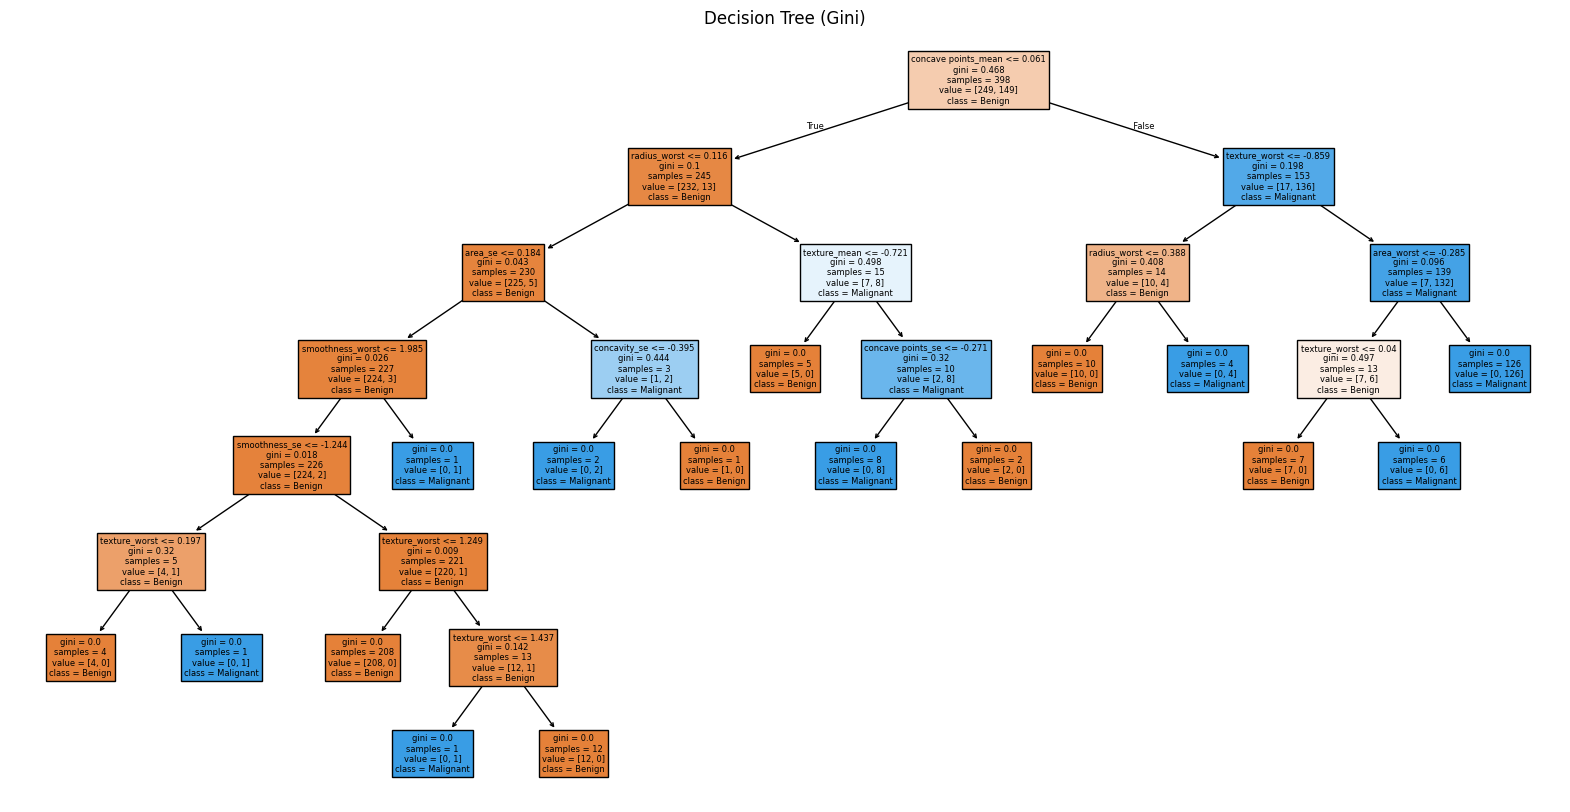

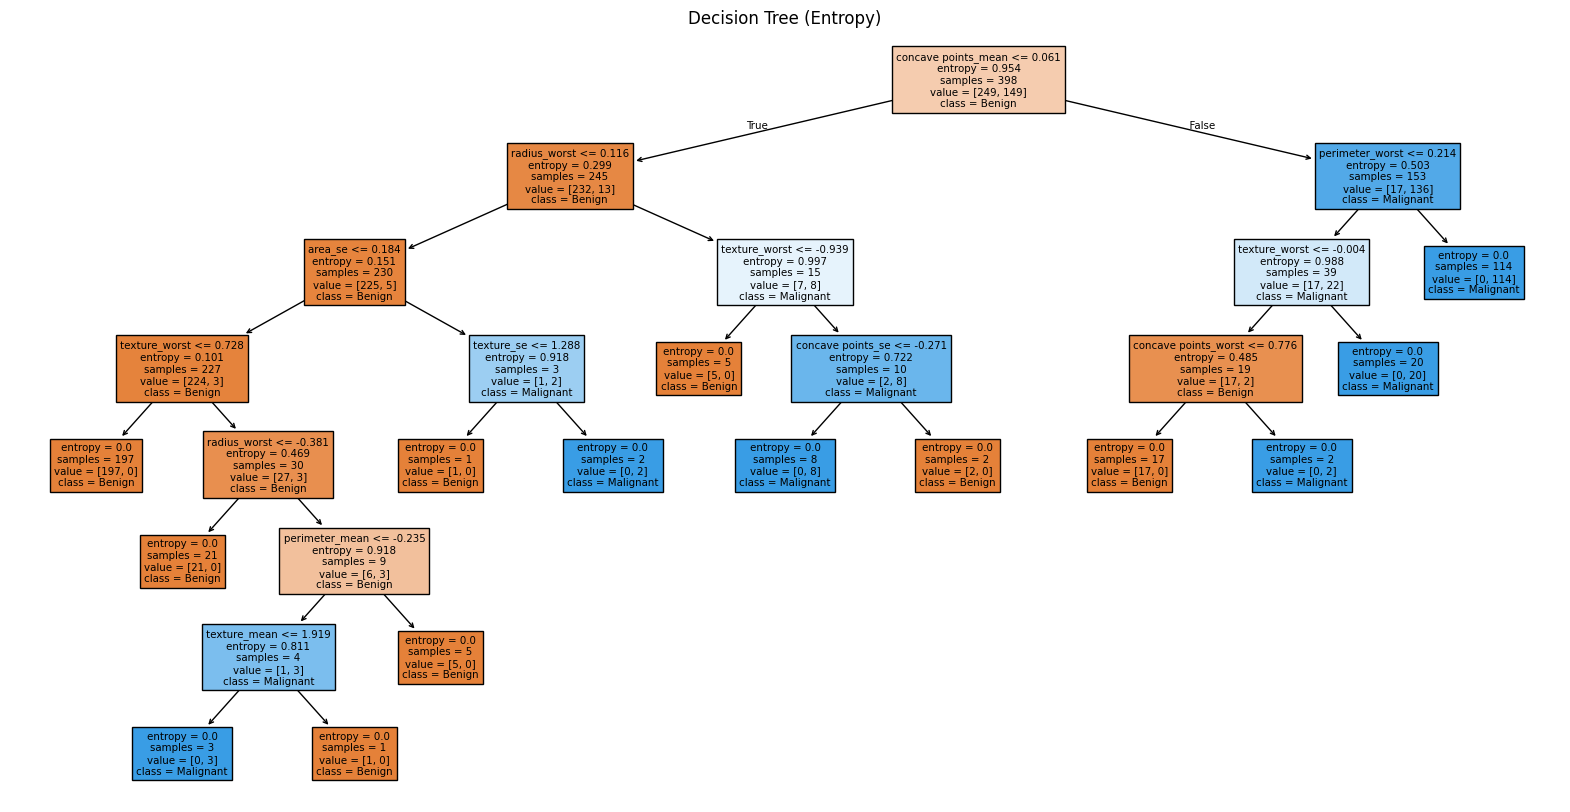


--- Association Rules ---
Empty DataFrame
Columns: [antecedents, consequents, support, confidence]
Index: []


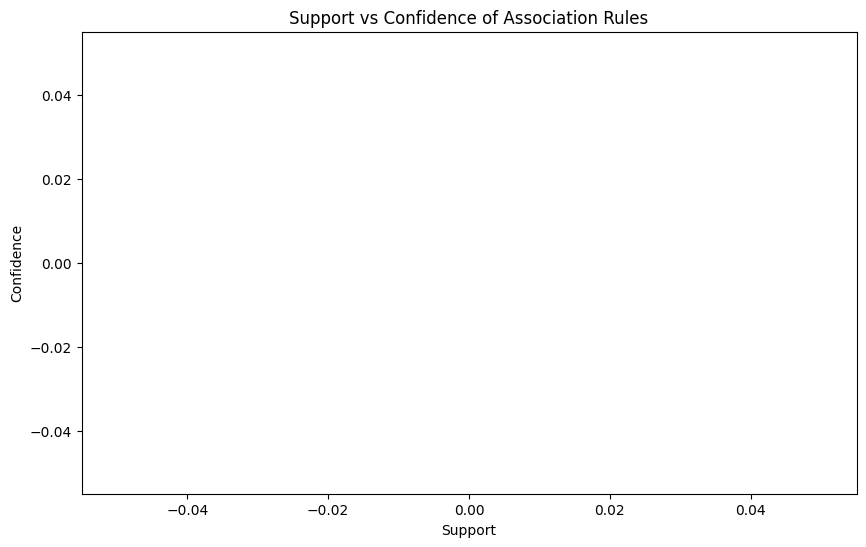

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load Breast Cancer dataset
df = pd.read_csv('/content/breast-cancer-wisconsin-data_data.csv')

# Drop unnecessary columns
df = df.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in df.columns])

# Encode the target variable (Diagnosis)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop any remaining NaN values
df.dropna(inplace=True)

# Features and Target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Decision Tree with Gini Impurity
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)
y_pred_gini = dt_gini.predict(X_test)

# Decision Tree with Entropy (Information Gain)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)
y_pred_entropy = dt_entropy.predict(X_test)

# Evaluate both models
def evaluate_model(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    return accuracy, precision, recall, f1, conf_matrix

# Gini Model Evaluation
accuracy_gini, precision_gini, recall_gini, f1_gini, conf_matrix_gini = evaluate_model(y_test, y_pred_gini)

# Entropy Model Evaluation
accuracy_entropy, precision_entropy, recall_entropy, f1_entropy, conf_matrix_entropy = evaluate_model(y_test, y_pred_entropy)

# Display results for classification
print("\n--- Decision Tree with Gini ---")
print(f"Accuracy: {accuracy_gini:.4f}")
print(f"Precision: {precision_gini:.4f}")
print(f"Recall: {recall_gini:.4f}")
print(f"F1 Score: {f1_gini:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_gini}")

print("\n--- Decision Tree with Entropy ---")
print(f"Accuracy: {accuracy_entropy:.4f}")
print(f"Precision: {precision_entropy:.4f}")
print(f"Recall: {recall_entropy:.4f}")
print(f"F1 Score: {f1_entropy:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_entropy}")

# Visualize the Decision Trees
plt.figure(figsize=(20, 10))
plot_tree(dt_gini, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree (Gini)")
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(dt_entropy, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True)
plt.title("Decision Tree (Entropy)")
plt.show()

# --- Association Rule Mining ---
# Create a binary dataframe for Association Rule Mining by applying thresholds
# We'll use 'mean radius' and 'mean texture' features for demonstration

# Binarizing features (setting a threshold)
bin_df = df[['radius_mean', 'texture_mean']].copy()

# Apply thresholds: You can choose these based on domain knowledge or experimentation
bin_df['radius_mean'] = bin_df['radius_mean'] > bin_df['radius_mean'].median()  # Binary based on median
bin_df['texture_mean'] = bin_df['texture_mean'] > bin_df['texture_mean'].median()  # Binary based on median

# Convert to boolean
bin_df = bin_df.astype(bool)

# Apply Transaction Encoder for the apriori algorithm
te = TransactionEncoder()
te_ary = te.fit_transform(bin_df.values.tolist())
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with min_support=0.3 (30% support)
frequent_itemsets = apriori(df_apriori, min_support=0.3, use_colnames=True)

# Find association rules with min confidence=0.7 (70% confidence)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Display the association rules
print("\n--- Association Rules ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence']])

# Optional: Additional analysis and visualization for association rules
plt.figure(figsize=(10, 6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.5)
plt.title("Support vs Confidence of Association Rules")
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Load Breast Cancer dataset
df = pd.read_csv('/content/breast-cancer-wisconsin-data_data.csv')

# Drop unnecessary columns
df = df.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in df.columns])

# Encode the target variable (Diagnosis)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Drop any remaining NaN values
df.dropna(inplace=True)

# Select a few more features for the association rule mining
# For simplicity, we'll use 'radius_mean', 'texture_mean', and 'perimeter_mean'
selected_features = df[['radius_mean', 'texture_mean', 'perimeter_mean']]

# Binarize the data based on a threshold (e.g., median or mean)
# We will try with the median here
bin_df = selected_features.copy()

# Apply median-based binarization
for column in bin_df.columns:
    bin_df[column] = bin_df[column] > bin_df[column].median()

# Convert to boolean (True/False)
bin_df = bin_df.astype(bool)

# Apply Transaction Encoder for the apriori algorithm
te = TransactionEncoder()
te_ary = te.fit_transform(bin_df.values.tolist())
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

# Find frequent itemsets with min_support=0.3 (30% support)
frequent_itemsets = apriori(df_apriori, min_support=0.3, use_colnames=True)

# Find association rules with min confidence=0.7 (70% confidence)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Display the association rules
print("\n--- Association Rules ---")
if rules.empty:
    print("No association rules found.")
else:
    print(rules[['antecedents', 'consequents', 'support', 'confidence']])

# Optional: Additional analysis and visualization for association rules
if not rules.empty:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(10, 6))
    plt.scatter(rules['support'], rules['confidence'], alpha=0.5)
    plt.title("Support vs Confidence of Association Rules")
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.show()



--- Association Rules ---
No association rules found.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# LOADING AND PREPROCESSING DATA
# ---------------------------
def load_data():
    """Load and preprocess the Breast Cancer Wisconsin dataset."""
    try:
        df = pd.read_csv('breast-cancer-wisconsin-data_data.csv')
        # Drop unnecessary columns
        df = df.drop(columns=[col for col in ['id', 'Unnamed: 32'] if col in df.columns])
        # Encode diagnosis: M -> 1 (Malignant), B -> 0 (Benign)
        df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
        # Drop rows with missing values
        df = df.dropna()
        return df
    except FileNotFoundError:
        print("Error: Dataset file not found. Please upload to Colab.")
        return None

df = load_data()
if df is None:
    raise SystemExit("Terminating due to missing dataset.")

print("\n--- Dataset Overview ---")
print(df.head())
print(f"Dataset Shape: {df.shape}")

# Standardize features
scaler = StandardScaler()
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
X_scaled = scaler.fit_transform(X)

# ---------------------------
# APPLICATIONS
# ---------------------------
print("""
APPLICATIONS:
1. Supports early breast cancer detection for medical professionals.
2. Minimizes invasive procedures through predictive analytics.
3. Enhances patient outcomes with data-driven insights.
4. Enables real-time decision-making in clinical settings.
5. Showcases data mining applications in healthcare.
""")

# ---------------------------
# CLASSIFICATION MODEL EVALUATION
# ---------------------------
def evaluate_model(name, model, X, y, test_size=0.25):
    """Train and evaluate a classification model."""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    return model

# Evaluate classifiers
nb_model = evaluate_model("Naive Bayes", GaussianNB(), X_scaled, y)
knn_model = evaluate_model("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5), X_scaled, y)
dt_gini_model = evaluate_model("Decision Tree (Gini)", DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42), X_scaled, y)
dt_entropy_model = evaluate_model("Decision Tree (Entropy)", DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42), X_scaled, y)

# ---------------------------
# DECISION TREE VISUALIZATION
# ---------------------------
plt.figure(figsize=(15, 8))
plot_tree(dt_entropy_model, feature_names=X.columns, class_names=['Benign', 'Malignant'], filled=True, rounded=True)
plt.title("Decision Tree (Entropy) Visualization")
plt.savefig('decision_tree_entropy.png')
plt.close()

# ---------------------------
# K-FOLD CROSS-VALIDATION
# ---------------------------
def cross_validation(models, X, y, k=5):
    """Perform k-fold cross-validation for given models."""
    print(f"\n--- {k}-Fold Cross-Validation ---")
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
        print(f"{name}: Mean Accuracy = {scores.mean():.4f}, Std = {scores.std():.4f}")

models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree (Gini)": DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42),
    "Decision Tree (Entropy)": DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
}
cross_validation(models, X_scaled, y, k=5)

# ---------------------------
# K-MEANS CLUSTERING
# ---------------------------
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)
y_kmeans = kmeans.labels_

plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, X.columns.get_loc('radius_mean')], X_scaled[:, X.columns.get_loc('texture_mean')], c=y_kmeans, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, X.columns.get_loc('radius_mean')], kmeans.cluster_centers_[:, X.columns.get_loc('texture_mean')], c='red', marker='x', s=200, label='Centroids')
plt.title("K-Means Clustering (2 Clusters)")
plt.xlabel("Radius Mean (Scaled)")
plt.ylabel("Texture Mean (Scaled)")
plt.legend()
plt.savefig('kmeans_clustering.png')
plt.close()

# ---------------------------
# PCA VISUALIZATION
# ---------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
components = pca.components_

# Identify the most contributing features for each PCA component
feature_contributions = pd.DataFrame(components, columns=X.columns)
primary_feature_pc1 = feature_contributions.iloc[0].abs().idxmax()
primary_feature_pc2 = feature_contributions.iloc[1].abs().idxmax()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.title(f"PCA Visualization (Explained Variance: {sum(explained_variance):.2%})")
plt.xlabel(f"{primary_feature_pc1} Component ({explained_variance[0]:.2%})")
plt.ylabel(f"{primary_feature_pc2} Component ({explained_variance[1]:.2%})")
plt.legend(handles=scatter.legend_elements()[0], labels=['Benign', 'Malignant'])
plt.savefig('pca_visualization.png')
plt.close()

# ---------------------------
# ASSOCIATION RULE MINING (APRIORI)
# ---------------------------
# Binary conversion for selected features
bin_df = df[['radius_mean', 'texture_mean']].copy()
bin_df['radius_mean'] = bin_df['radius_mean'] > bin_df['radius_mean'].median()
bin_df['texture_mean'] = bin_df['texture_mean'] > bin_df['texture_mean'].median()
bin_df = bin_df.astype(bool)

# Apply TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit_transform(bin_df.values.tolist())
df_apriori = pd.DataFrame(te_ary, columns=te.columns_)

# Run Apriori algorithm
frequent_itemsets = apriori(df_apriori, min_support=0.3, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print("\n--- Association Rules ---")
print(rules[['antecedents', 'consequents', 'support', 'confidence']].to_string(index=False))

# ---------------------------
# SUMMARY
# ---------------------------
print("""
SUMMARY:
1. Preprocessed data with standardization for consistent model performance.
2. Evaluated Naive Bayes, KNN, and Decision Trees (Gini, Entropy) with accuracy, precision, recall, and F1 score.
3. Visualized Decision Tree (Entropy) for interpretability.
4. Performed 5-fold cross-validation to assess model robustness.
5. Applied K-Means clustering to identify natural data groupings using radius_mean and texture_mean.
6. Used PCA for 2D visualization, highlighting primary contributing features.
7. Conducted association rule mining with Apriori on binary-converted features.
8. Demonstrated applications in medical diagnosis and predictive analytics.
""")



--- Dataset Overview ---
   diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0          1        17.99         10.38          122.80     1001.0   
1          1        20.57         17.77          132.90     1326.0   
2          1        19.69         21.25          130.00     1203.0   
3          1        11.42         20.38           77.58      386.1   
4          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  .